In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load the dataset
df = pd.read_csv('Churn_Modelling.csv')

# First look at the data
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (10000, 14)

First 5 rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Explore the data
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nChurn vs Retained:")
print(df['Exited'].value_counts())
print("\nChurn percentage:")
print(df['Exited'].value_counts(normalize=True) * 100)

Shape: (10000, 14)

Missing values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Churn vs Retained:
Exited
0    7963
1    2037
Name: count, dtype: int64

Churn percentage:
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


/var/folders/5r/h9_nf6b53d9652pvmddrlxfr0000gn/T/ipykernel_7183/3729995372.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Retained', 'Churned'])


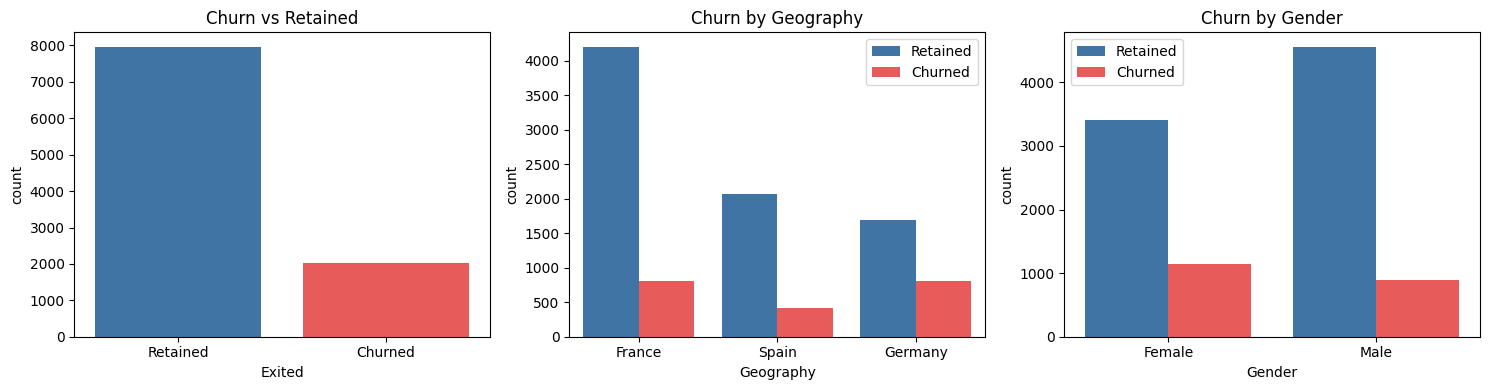

In [4]:
# Visualise churn distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Churn count
sns.countplot(x='Exited', data=df, hue='Exited',
              palette={0:'#2E75B6', 1:'#FF4444'}, 
              legend=False, ax=axes[0])
axes[0].set_title('Churn vs Retained')
axes[0].set_xticklabels(['Retained', 'Churned'])

# Churn by Geography
sns.countplot(x='Geography', data=df, hue='Exited',
              palette={0:'#2E75B6', 1:'#FF4444'}, ax=axes[1])
axes[1].set_title('Churn by Geography')
axes[1].legend(['Retained', 'Churned'])

# Churn by Gender
sns.countplot(x='Gender', data=df, hue='Exited',
              palette={0:'#2E75B6', 1:'#FF4444'}, ax=axes[2])
axes[2].set_title('Churn by Gender')
axes[2].legend(['Retained', 'Churned'])

plt.tight_layout()
plt.show()

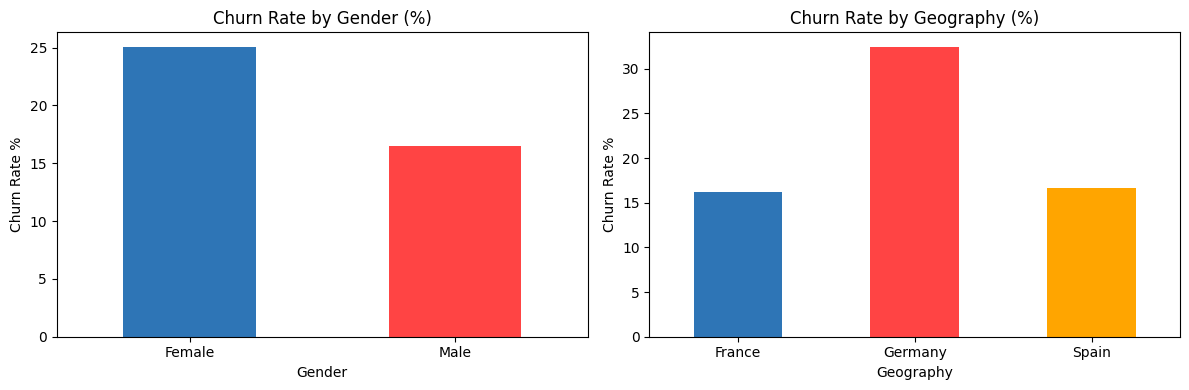

In [5]:
# Churn rate by gender as percentage
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Churn rate by Gender
gender_churn = df.groupby('Gender')['Exited'].mean() * 100
gender_churn.plot(kind='bar', color=['#2E75B6', '#FF4444'], ax=axes[0])
axes[0].set_title('Churn Rate by Gender (%)')
axes[0].set_ylabel('Churn Rate %')
axes[0].set_xticklabels(['Female', 'Male'], rotation=0)

# Churn rate by Geography
geo_churn = df.groupby('Geography')['Exited'].mean() * 100
geo_churn.plot(kind='bar', color=['#2E75B6', '#FF4444', '#FFA500'], ax=axes[1])
axes[1].set_title('Churn Rate by Geography (%)')
axes[1].set_ylabel('Churn Rate %')
axes[1].set_xticklabels(['France', 'Germany', 'Spain'], rotation=0)

plt.tight_layout()
plt.show()

In [6]:
# Drop columns we don't need
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Encode categorical variables
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['Geography'] = le.fit_transform(df['Geography'])

# Split features and target
X = df.drop('Exited', axis=1)
y = df['Exited']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE - Churn:", sum(y_train == 1), "| Retained:", sum(y_train == 0))
print("After SMOTE  - Churn:", sum(y_train_smote == 1), "| Retained:", sum(y_train_smote == 0))

Before SMOTE - Churn: 1630 | Retained: 6370
After SMOTE  - Churn: 6370 | Retained: 6370


In [7]:
# Train all three models
print("Training Logistic Regression...")
lr = LogisticRegression(random_state=42)
lr.fit(X_train_smote, y_train_smote)
lr_pred = lr.predict(X_test)

print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_smote, y_train_smote)
rf_pred = rf.predict(X_test)

print("Training Gradient Boosting...")
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_smote, y_train_smote)
gb_pred = gb.predict(X_test)

print("\nAll models trained!")

Training Logistic Regression...
Training Random Forest...
Training Gradient Boosting...

All models trained!


In [8]:
# Evaluate all models
models = {
    'Logistic Regression': lr_pred,
    'Random Forest': rf_pred,
    'Gradient Boosting': gb_pred
}

for name, pred in models.items():
    print(f"\n{'='*50}")
    print(f"{name}")
    print('='*50)
    print(classification_report(y_test, pred, 
          target_names=['Retained', 'Churned']))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, pred):.4f}")


Logistic Regression
              precision    recall  f1-score   support

    Retained       0.91      0.70      0.79      1593
     Churned       0.38      0.72      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.73      2000

ROC-AUC Score: 0.7124

Random Forest
              precision    recall  f1-score   support

    Retained       0.89      0.91      0.90      1593
     Churned       0.62      0.58      0.60       407

    accuracy                           0.84      2000
   macro avg       0.76      0.74      0.75      2000
weighted avg       0.84      0.84      0.84      2000

ROC-AUC Score: 0.7447

Gradient Boosting
              precision    recall  f1-score   support

    Retained       0.91      0.88      0.89      1593
     Churned       0.58      0.67      0.62       407

    accuracy                           0.83      2000
   macro avg       0.75      

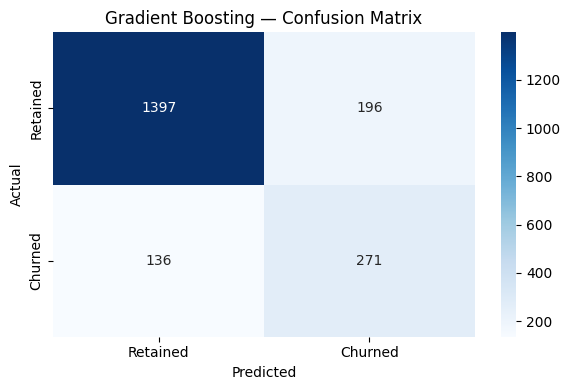

In [9]:
# Confusion matrix for best model
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, gb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'])
plt.title('Gradient Boosting — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [11]:
# Final summary
print("=" * 55)
print("BANK CHURN PREDICTION — MODEL COMPARISON SUMMARY")
print("=" * 55)
print(f"Logistic Regression  - Churn F1: 0.50 | ROC-AUC: 0.71")
print(f"Random Forest        - Churn F1: 0.60 | ROC-AUC: 0.74")
print(f"Gradient Boosting    - Churn F1: 0.62 | ROC-AUC: 0.77")
print("\nConclusion: Gradient Boosting delivers the best")
print("overall performance for bank customer churn prediction.")
print("\nKey Insights:")
print("- Female customers churn at a higher rate than males")
print("- Germany has the highest churn rate by geography")
print("- Gradient Boosting correctly identified 271/407 churning customers")

BANK CHURN PREDICTION — MODEL COMPARISON SUMMARY
Logistic Regression  - Churn F1: 0.50 | ROC-AUC: 0.71
Random Forest        - Churn F1: 0.60 | ROC-AUC: 0.74
Gradient Boosting    - Churn F1: 0.62 | ROC-AUC: 0.77

Conclusion: Gradient Boosting delivers the best
overall performance for bank customer churn prediction.

Key Insights:
- Female customers churn at a higher rate than males
- Germany has the highest churn rate by geography
- Gradient Boosting correctly identified 271/407 churning customers


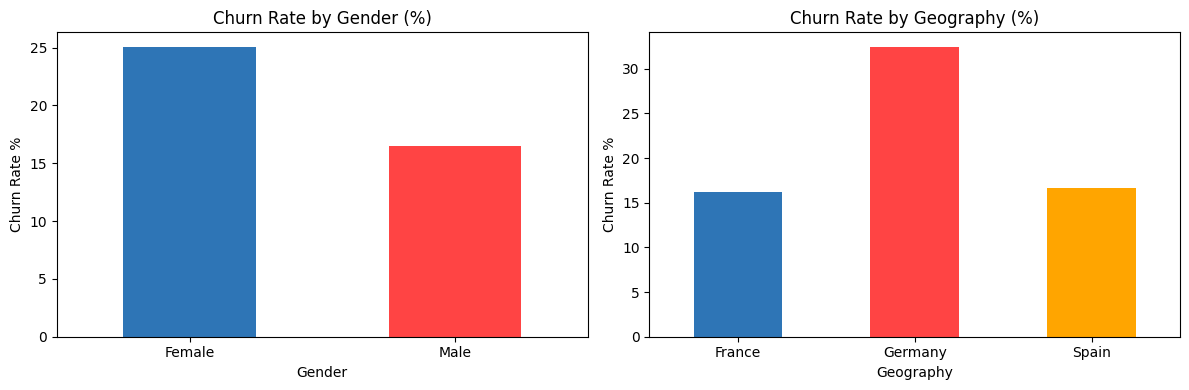

Image saved!


In [12]:
# Save charts as images for GitHub README
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

gender_churn = df.groupby('Gender')['Exited'].mean() * 100
gender_churn.plot(kind='bar', color=['#2E75B6', '#FF4444'], ax=axes[0])
axes[0].set_title('Churn Rate by Gender (%)')
axes[0].set_ylabel('Churn Rate %')
axes[0].set_xticklabels(['Female', 'Male'], rotation=0)

geo_churn = df.groupby('Geography')['Exited'].mean() * 100
geo_churn.plot(kind='bar', color=['#2E75B6', '#FF4444', '#FFA500'], ax=axes[1])
axes[1].set_title('Churn Rate by Geography (%)')
axes[1].set_ylabel('Churn Rate %')
axes[1].set_xticklabels(['France', 'Germany', 'Spain'], rotation=0)

plt.tight_layout()
plt.savefig('churn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Image saved!")